In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pandas as pd
live_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [1756,2030,1700,2148,1678,1844,1628,2115,2341,2262,2568,2478,2498,3434,5492,5208,4199,4373,5080,5488,5493,6703,7034,10179,7287,4379,7032,7824],
             'Price':[21.31,33.97,29.34,47.08,37.99,39.88,40.57,53.66,51.1,50.75,61.71,64.06,69.07,99,139.14,142.15,154.61,197.89,281.85,301.51,308.81,403.75,286.11,388.88,324.26,239.69,353.36,440.06]}
df6=pd.DataFrame(live_fish)

Dataset has 28 records and 3 columns


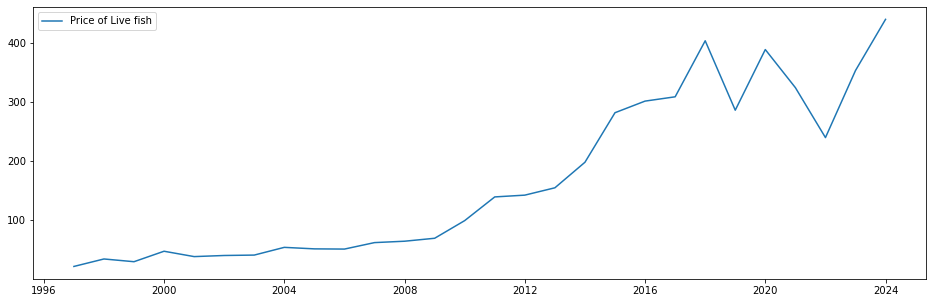

Results of Dickey-Fuller Test:
Test Statistic                 -0.225850
p-value                         0.935369
#Lags Used                      0.000000
Number of Observations Used    27.000000
Critical Value (1%)            -3.699608
Critical Value (5%)            -2.976430
Critical Value (10%)           -2.627601
dtype: float64


In [3]:
# Check the dimensionality of the dataset
df6.shape
print("Dataset has {} records and {} columns".format(df6.shape[0], df6.shape[1]))
# Changing the YEAR data type and setting it as index
df6['YEAR'] = pd.Index(sm.tsa.datetools.dates_from_range('1996', '2023'))
df6.index = df6['YEAR']
# Check the data type
del df6['YEAR']
# View the dataset
df6.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df6.index, df6['Price'], label = "Price of Live fish")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df6test = adfuller(timeseries, autolag='AIC')
    df6output = pd.Series(df6test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df6test[4].items():
        df6output['Critical Value (%s)'%key] = value
    print (df6output)
# Call the function and run the test

adf_test(df6['Price'])


In [4]:
df6['Price_diff'] =df6['Price'].diff()
df6= df6.dropna()


In [5]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df6test = adfuller(df6['Price_diff'],autolag='AIC')
df6output=pd.Series(df6test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df6test[4].items():
    df6output['critical value (%s)'%key]= value
print(df6output)

Results of Dickey-fuller test:
Test Statistic :                -6.573028e+00
p-value :                        7.849338e-09
#lags used :                     0.000000e+00
number of observations used :    2.600000e+01
critical value (1%)             -3.711212e+00
critical value (5%)             -2.981247e+00
critical value (10%)            -2.630095e+00
dtype: float64


In [6]:
7.893338e-09>0.05

False

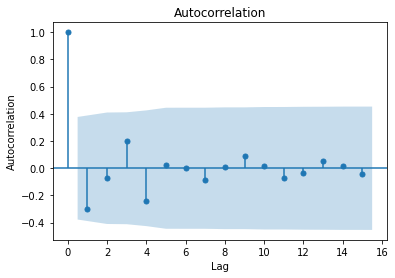

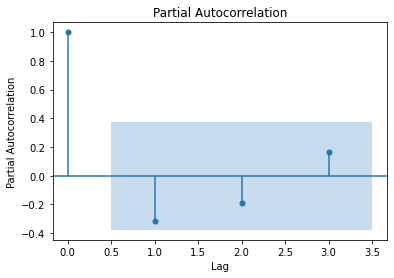

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df6['Price_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=3)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

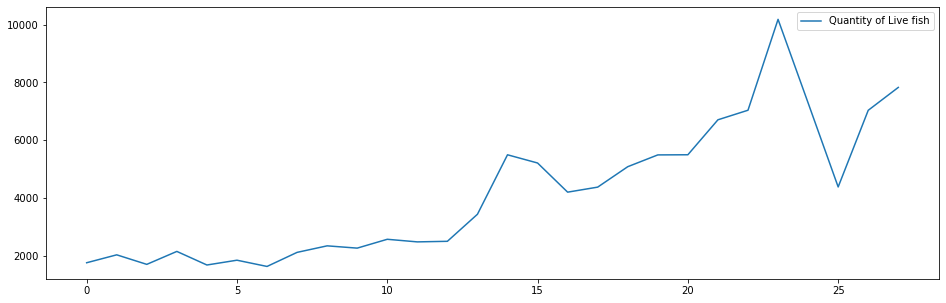

Results of Dickey-Fuller Test:
Test Statistic                 -0.580296
p-value                         0.875372
#Lags Used                      9.000000
Number of Observations Used    18.000000
Critical Value (1%)            -3.859073
Critical Value (5%)            -3.042046
Critical Value (10%)           -2.660906
dtype: float64


In [16]:
# Quantity
#Check the dimensionality of the dataset
df6.shape
df6.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df6.index, df6['Quantity'], label = "Quantity of Live fish")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df6test = adfuller(timeseries, autolag='AIC')
    df6output = pd.Series(df6test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df6test[4].items():
        df6output['Critical Value (%s)'%key] = value
    print (df6output)
# Call the function and run the test

adf_test(df6['Quantity'])


In [17]:
df6['Quantity_diff']=df6['Quantity'].diff()
df6=df6.dropna()


In [18]:
df6['Quantity_diff_2'] =df6['Quantity_diff'].diff()
df6= df6.dropna()
df6['Quantity_diff_3'] =df6['Quantity_diff_2'].diff()
df6= df6.dropna()

In [19]:
df6['Quantity_diff_4'] =df6['Quantity_diff_3'].diff()
df6= df6.dropna()


In [34]:
df6['Quantity_diff_5'] =df6['Quantity_diff_4'].diff()
df6= df6.dropna()


In [28]:

# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df6test = adfuller(timeseries, autolag='AIC')
    df6output = pd.Series(df6test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df6test[4].items():
        df6output['Critical Value (%s)'%key] = value
    print (df6output)
# Call the function and run the test

adf_test(df6['Quantity_diff_3'])



Results of Dickey-Fuller Test:
Test Statistic                 -4.203326
p-value                         0.000650
#Lags Used                      7.000000
Number of Observations Used    16.000000
Critical Value (1%)            -3.924019
Critical Value (5%)            -3.068498
Critical Value (10%)           -2.673893
dtype: float64


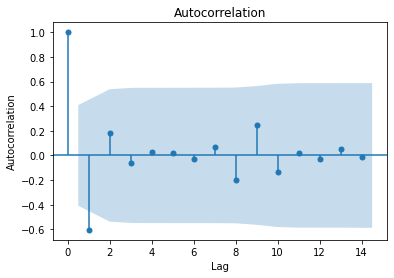

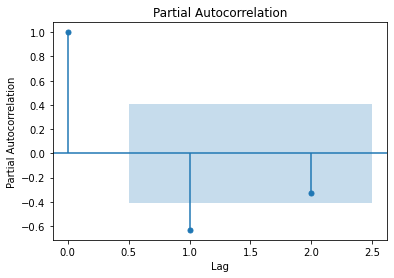

In [35]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df6['Quantity_diff_5'].values
#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=2)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

In [50]:
#2 nd objectieve
#Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df6['Quantity'])

# Fit the OLS model
model = sm.OLS(df6['Price'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = -56.90262252599233 + 0.05416427177492719 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     135.3
Date:                Sun, 16 Jul 2023   Prob (F-statistic):           4.11e-11
Time:                        20:18:09   Log-Likelihood:                -133.70
No. Observations:                  25   AIC:                             271.4
Df Residuals:                      23   BIC:                             273.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [127]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df6[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 

# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Estimated Coefficients:
[[[ 7.63658565e-01 -6.63351180e+00]
  [-5.84050034e-04  6.36001600e-01]]

 [[-8.82085288e-01  2.50438004e+01]
  [-2.01885447e-02  7.18108266e-01]]]
Forecasted Values:
[[ 7680.56338593   435.80675587]
 [ 9071.9266773    479.45611925]
 [ 9864.91053459   506.24604516]
 [10158.61301269   526.0767073 ]
 [10222.79665686   541.74638041]
 [10405.4305941    559.98596793]
 [10759.72076262   581.43645484]
 [11183.6753058    604.28296082]
 [11580.56682375   626.81693358]
 [11932.37632638   648.76401137]]


In [133]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df6[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 
parameters = results.params
print("Parameter Estimates:")
print(parameters)
print("\n")

# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Parameter Estimates:
                Quantity      Price
const        1978.188421  48.712609
L1.Quantity     0.763659  -0.000584
L1.Price       -6.633512   0.636002
L2.Quantity    -0.882085  -0.020189
L2.Price       25.043800   0.718108


Estimated Coefficients:
[[[ 7.63658565e-01 -6.63351180e+00]
  [-5.84050034e-04  6.36001600e-01]]

 [[-8.82085288e-01  2.50438004e+01]
  [-2.01885447e-02  7.18108266e-01]]]
Forecasted Values:
[[ 7680.56338593   435.80675587]
 [ 9071.9266773    479.45611925]
 [ 9864.91053459   506.24604516]
 [10158.61301269   526.0767073 ]
 [10222.79665686   541.74638041]
 [10405.4305941    559.98596793]
 [10759.72076262   581.43645484]
 [11183.6753058    604.28296082]
 [11580.56682375   626.81693358]
 [11932.37632638   648.76401137]]


In [1]:
import pandas as pd
live_fish = {'Year': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22','2022-23'],
        'Quantity': [1756,2030,1700,2148,1678,1844,1628,2115,2341,2262,2568,2478,2498,3434,5492,5208,4199,4373,5080,5488,5493,6703,7034,10179,7287,4379,7032,7824],
             'Price':[21.31,33.97,29.34,47.08,37.99,39.88,40.57,53.66,51.1,50.75,61.71,64.06,69.07,99,139.14,142.15,154.61,197.89,281.85,301.51,308.81,403.75,286.11,388.88,324.26,239.69,353.36,440.06]}
df6=pd.DataFrame(live_fish)

In [6]:
# Assuming you have a DataFrame 'data' containing the price and quantity variables.
# We'll use the ADF test to check for stationarity.
from statsmodels.tsa.stattools import adfuller
data=df6[['Price','Quantity']]
def are_series_stationary(data, threshold=0.05):
    result = adfuller(data)
    p_value = result[1]
    return p_value <= threshold

# Test for stationarity of price and quantity
is_price_stationary = are_series_stationary(df6['Price'])
is_quantity_stationary = are_series_stationary(df6['Quantity'])

# If both series are non-stationary, proceed with cointegration test
if not is_price_stationary and not is_quantity_stationary:
    result = coint_johansen(data, det_order=0, k_ar_diff=1)

    # Get the trace statistics and critical values for different significance levels (e.g., 90%, 95%, 99%)
    trace_statistic = result.lr1
    trace_critical_values = result.cvt[:, 1]  # Use 1% critical value (you can choose other values as well)

    # Find the number of cointegrated vectors (relationships)
    num_cointegrated_vectors = sum(trace_statistic > trace_critical_values)

    if num_cointegrated_vectors > 0:
        print("The variables price and quantity are cointegrated.")
    else:
        print("The variables price and quantity are not cointegrated.")
else:
    print("Both variables should be non-stationary for cointegration testing.")


The variables price and quantity are cointegrated.


In [7]:
num_cointegrated_vectors

1

In [3]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df6[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit()
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[7416.40764782  413.46703322]
 [8143.0862776   421.12306639]
 [8677.26294383  424.82180708]
 [9053.81863834  428.23949856]
 [9277.41731706  430.2889004 ]
 [9402.84631025  431.48835531]
 [9469.45068654  432.13745724]
 [9503.50654271  432.4758002 ]
 [9520.34050694  432.64560148]
 [9528.41541667  432.72824401]]


(array([[7416.40764782,  413.46703322],
        [8143.0862776 ,  421.12306639],
        [8677.26294383,  424.82180708],
        [9053.81863834,  428.23949856],
        [9277.41731706,  430.2889004 ],
        [9402.84631025,  431.48835531],
        [9469.45068654,  432.13745724],
        [9503.50654271,  432.4758002 ],
        [9520.34050694,  432.64560148],
        [9528.41541667,  432.72824401]]),
 array([[5105.67650229,  309.68785885],
        [5069.59552552,  290.54734254],
        [5101.32002545,  269.85191878],
        [5079.55547144,  251.99716469],
        [4927.63353609,  234.556446  ],
        [4687.19680889,  217.74260911],
        [4399.36391002,  201.60649262],
        [4093.51638203,  186.20905967],
        [3786.05193353,  171.5431627 ],
        [3485.00071758,  157.5662801 ]]),
 array([[ 9727.13879335,   517.2462076 ],
        [11216.57702967,   551.69879024],
        [12253.2058622 ,   579.79169537],
        [13028.08180525,   604.48183244],
        [13627.20109803,   6

In [9]:
coint_vectors

array([[ 8.59211080e-04, -1.38692533e-05],
       [-1.89295545e-02,  5.52233357e-03]])

In [5]:

vecm_res = model.fit()
vecm_res.gamma.round(4)
vecm_res.summary()
print(model)
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,0.4302,0.292,1.471,0.141,-0.143,1.003
L1.Price,-15.0336,7.129,-2.109,0.035,-29.007,-1.060
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,0.0086,0.013,0.656,0.512,-0.017,0.034
L1.Price,-0.3941,0.320,-1.231,0.218,-1.022,0.233
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.2967,0.199,-1.493,0.135,-0.686,0.093
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.0004,0.009,-0.045,0.964,-0.018,0.017
,coef,std err,z,P>|z|,[0.025,0.975]


lower bounds of confidence intervals:
[[5105.677  309.688]
 [5069.596  290.547]
 [5101.32   269.852]
 [5079.555  251.997]
 [4927.634  234.556]]

point forecasts:
[[7416.408  413.467]
 [8143.086  421.123]
 [8677.263  424.822]
 [9053.819  428.239]
 [9277.417  430.289]]

upper bounds of confidence intervals:
[[ 9727.139   517.246]
 [11216.577   551.699]
 [12253.206   579.792]
 [13028.082   604.482]
 [13627.201   626.021]]


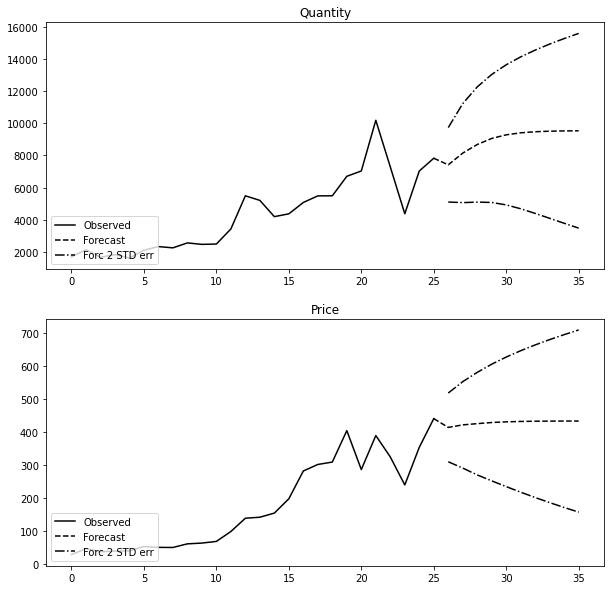

In [6]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)
